# Task 1: Historical Value at Risk (VaR) & Conditional Value at Risk (CVaR)

## Objective
Estimate the downside risk of each mutual fund using Historical Simulation based on daily NAV returns.

### Dataset
- clean_nav.csv
- clean_performance.csv

### Output
reports/var_cvar_report.csv

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

In [3]:
nav = pd.read_csv(
    DATA_PROCESSED / "clean_nav.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    DATA_PROCESSED / "clean_performance.csv"
)

print(nav.head())

print(performance.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct        

In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav = nav.dropna(
    subset=["daily_return"]
)

print(nav.shape)

(45960, 4)


In [7]:
confidence = 0.95

results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"]

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append({

        "amfi_code": amfi_code,

        "VaR_95": round(var95,6),

        "CVaR_95": round(cvar95,6)

    })

var_df = pd.DataFrame(results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_df = var_df.merge(

    performance[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

var_df = var_df[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95",
        "CVaR_95"
    ]
]

var_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [9]:
output_file = REPORTS / "var_cvar_report.csv"

var_df.to_csv(
    output_file,
    index=False
)

print("Saved Successfully")

print(output_file)

Saved Successfully
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\var_cvar_report.csv


In [10]:
print("Highest Risk Funds")
display(var_df.sort_values(by="VaR_95").head(10))

Highest Risk Funds


,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [11]:
print("Lowest Risk Funds")
display(var_df.sort_values(by="VaR_95",ascending=False).head(10))

Lowest Risk Funds


,amfi_code,scheme_name,VaR_95,CVaR_95
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000222,-0.000373
5,101208,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
31,120844,Kotak Liquid Fund - Regular - Growth,-0.000285,-0.000411
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.003804,-0.004919
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.003938,-0.005014
12,118635,Nippon India ETF Nifty 50 BeES,-0.012554,-0.016177
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.012613,-0.015490
19,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.012846,-0.016397
28,120841,Kotak Bluechip Fund - Regular - Growth,-0.013142,-0.016363


# Task 2: Rolling 90-Day Sharpe Ratio

## Objective
Calculate the rolling 90-day Sharpe Ratio for each mutual fund using daily NAV returns.

### Output
reports/rolling_sharpe_chart.png

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

nav = pd.read_csv(
    DATA_PROCESSED / "clean_nav.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    DATA_PROCESSED / "clean_performance.csv"
)

In [14]:
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())
nav = nav.dropna()

In [15]:
risk_free_rate = 0.05

daily_rf = risk_free_rate / 252

nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
            lambda x: x.rolling(90).mean()
       )
)

nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
            lambda x: x.rolling(90).std()
       )
)

nav["rolling_sharpe"] = (
    (nav["rolling_mean"] - daily_rf)
    /
    nav["rolling_std"]
)

In [16]:
top5 = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top5_codes = top5["amfi_code"]

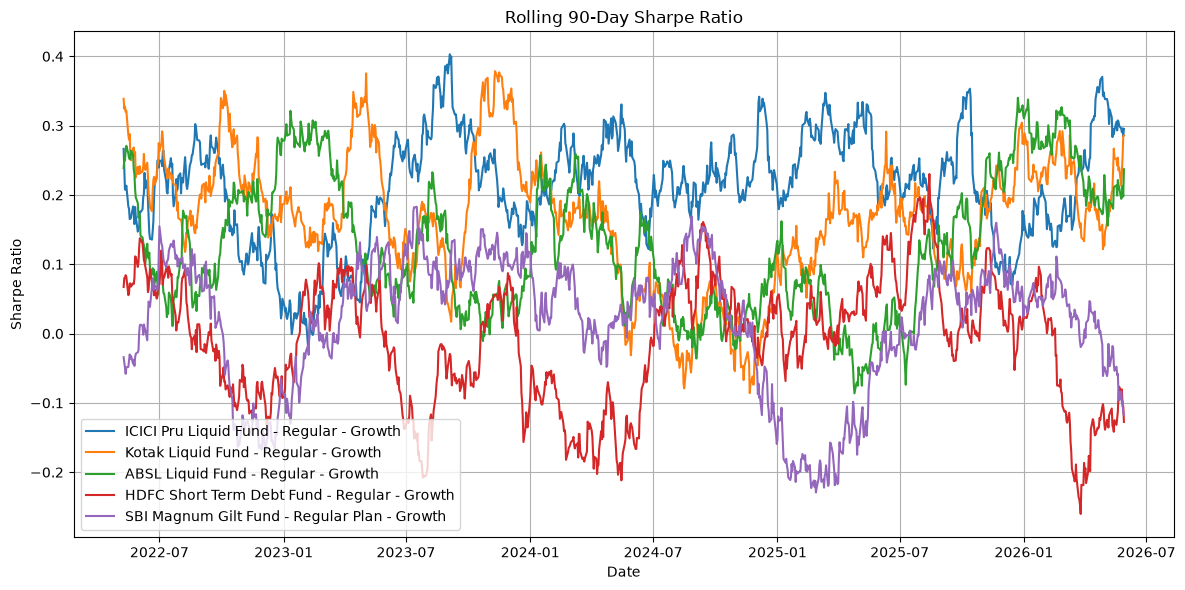

In [17]:
plt.figure(figsize=(12,6))

for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ]

    scheme = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

In [18]:
output = REPORTS / "rolling_sharpe_chart.png"

plt.savefig(
    output,
    dpi=300
)

plt.show()

print("Saved Successfully")

print(output)

<Figure size 640x480 with 0 Axes>

Saved Successfully
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\rolling_sharpe_chart.png


# Task 3: Investor Cohort Analysis

## Objective
Analyze investor cohorts based on the year of their first transaction.

### Metrics
- Total Investors
- Total Investment
- Average Investment
- Preferred Transaction Type

### Output
reports/cohort_analysis.csv

In [19]:
import pandas as pd
from pathlib import Path

In [20]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

In [21]:
transactions = pd.read_csv(
    DATA_PROCESSED / "clean_transactions.csv",
    parse_dates=["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [23]:
transactions = transactions.merge(first_transaction[["investor_id","cohort_year"]],on="investor_id",how="left")
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [24]:
cohort = (
    transactions.groupby("cohort_year").agg(
        Total_Investors=("investor_id","nunique"),
        Total_Investment=("amount_inr","sum"),
        Average_Investment=("amount_inr","mean")
    ).reset_index()
)

In [25]:
preferred = (
    transactions
    .groupby(
        ["cohort_year","transaction_type"]
    )
    .size()
    .reset_index(name="count")
)

preferred = (
    preferred
    .sort_values(
        "count",
        ascending=False
    )
    .drop_duplicates("cohort_year")
)

preferred = preferred[
    ["cohort_year","transaction_type"]
]

In [26]:
cohort = cohort.merge(
    preferred,
    on="cohort_year",
    how="left"
)

cohort.rename(
    columns={
        "transaction_type":"Preferred_Transaction_Type"
    },
    inplace=True
)
cohort

,cohort_year,Total_Investors,Total_Investment,Average_Investment,Preferred_Transaction_Type
0,2024,4803,3491125187,107422.541832,SIP
1,2025,197,30455243,109158.577061,SIP


In [27]:
output = REPORTS / "cohort_analysis.csv"
cohort.to_csv(output,index=False)

print("Saved Successfully")
print(output)

Saved Successfully
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\cohort_analysis.csv


In [28]:
print("Investor Cohort Analysis")
display(cohort)

Investor Cohort Analysis


,cohort_year,Total_Investors,Total_Investment,Average_Investment,Preferred_Transaction_Type
0,2024,4803,3491125187,107422.541832,SIP
1,2025,197,30455243,109158.577061,SIP


# Task 4: SIP Continuity Analysis

## Objective
Analyze the average gap between consecutive investor transactions.

### Criteria
- Average Gap ≤ 35 days → Active
- Average Gap > 35 days → At Risk

### Output
reports/sip_continuity.csv

In [29]:
import pandas as pd
from pathlib import Path

In [30]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

In [31]:
transactions = pd.read_csv(
    DATA_PROCESSED / "clean_transactions.csv",
    parse_dates=["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [32]:
transactions = transactions.sort_values(["investor_id", "transaction_date"])

In [33]:
transactions["gap_days"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0


In [34]:
sip_gap = (
    transactions
    .groupby("investor_id")
    .agg(
        Average_Gap_Days=("gap_days", "mean"),
        Total_Transactions=("transaction_date", "count"),
        Total_Investment=("amount_inr", "sum")
    )
    .reset_index()
)

In [35]:
sip_gap["SIP_Status"] = sip_gap["Average_Gap_Days"].apply(

    lambda x: "At Risk"
    if pd.notna(x) and x > 35
    else "Active"

)

In [36]:
output = REPORTS / "sip_continuity.csv"
sip_gap.to_csv(output,index=False)

print("Saved Successfully")
print(output)

Saved Successfully
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\sip_continuity.csv


# Task 6: Sector Concentration Analysis (HHI)

## Objective

Calculate the Herfindahl-Hirschman Index (HHI) for every mutual fund.

HHI measures how concentrated a portfolio is.

Output:
reports/sector_hhi.csv

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"

REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

In [3]:
portfolio = pd.read_csv(
    DATA_RAW / "09_portfolio_holdings.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [4]:
portfolio["weight_fraction"] = portfolio["weight_pct"] / 100

portfolio["weight_square"] = portfolio["weight_fraction"] ** 2

In [5]:
hhi = (
    portfolio
    .groupby("amfi_code")
    .agg(
        HHI=("weight_square","sum")
    )
    .reset_index()
)

In [6]:
performance = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "clean_performance.csv"
)

hhi = hhi.merge(

    performance[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [7]:
def classify(h):

    if h < 0.15:
        return "Low"

    elif h < 0.25:
        return "Moderate"

    else:
        return "High"


hhi["Risk_Level"] = hhi["HHI"].apply(classify)

In [8]:
hhi["HHI"] = (hhi["HHI"] * 10000).round(2)

In [9]:
hhi = hhi[
    [
        "amfi_code",
        "scheme_name",
        "HHI",
        "Risk_Level"
    ]
]

hhi.head()

,amfi_code,scheme_name,HHI,Risk_Level
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1395.34,Low
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1475.92,Low
2,101206,ABSL Frontline Equity Fund - Regular - Growth,1293.32,Low
3,101207,ABSL Small Cap Fund - Regular - Growth,2007.00,Moderate
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,1747.09,Moderate


In [10]:
output = REPORTS / "sector_hhi.csv"

hhi.to_csv(
    output,
    index=False
)

print("Saved Successfully")

print(output)

Saved Successfully
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\sector_hhi.csv


# Task 7: Advanced Analytics Summary

## Objective

Summarize the key findings from:

- Historical VaR & CVaR
- Rolling Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Sector Concentration Analysis

### Output

reports/advanced_analytics_summary.md

In [11]:
from pathlib import Path
import pandas as pd

In [12]:
PROJECT_ROOT = Path.cwd().parent

REPORTS = PROJECT_ROOT / "reports"

In [13]:
var_df = pd.read_csv(REPORTS / "var_cvar_report.csv")

cohort = pd.read_csv(REPORTS / "cohort_analysis.csv")

sip = pd.read_csv(REPORTS / "sip_continuity.csv")

hhi = pd.read_csv(REPORTS / "sector_hhi.csv")

In [14]:
highest_risk = var_df.loc[var_df["VaR_95"].idxmin()]

lowest_risk = var_df.loc[var_df["VaR_95"].idxmax()]

largest_cohort = cohort.loc[
    cohort["Total_Investors"].idxmax()
]

highest_hhi = hhi.loc[
    hhi["HHI"].idxmax()
]

active_pct = (
    (sip["SIP_Status"] == "Active").mean() * 100
)

In [15]:
summary = f"""
# Advanced Analytics Summary

## 1. Historical Risk Analysis

Highest Risk Fund:
- {highest_risk['scheme_name']}
- VaR (95%): {highest_risk['VaR_95']:.4f}
- CVaR (95%): {highest_risk['CVaR_95']:.4f}

Lowest Risk Fund:
- {lowest_risk['scheme_name']}
- VaR (95%): {lowest_risk['VaR_95']:.4f}
- CVaR (95%): {lowest_risk['CVaR_95']:.4f}

---

## 2. Investor Cohort Analysis

Largest Investor Cohort:
- Year: {largest_cohort['cohort_year']}
- Investors: {largest_cohort['Total_Investors']}
- Total Investment: ₹{largest_cohort['Total_Investment']:,.2f}

---

## 3. SIP Continuity

Percentage of Active Investors:

{active_pct:.2f}%

---

## 4. Portfolio Concentration

Highest Portfolio Concentration:

{highest_hhi['scheme_name']}

HHI: {highest_hhi['HHI']}

Risk Level: {highest_hhi['Risk_Level']}

---

## Overall Conclusion

• Most investors maintain regular investment activity.

• Portfolio concentration varies across mutual fund schemes.

• Historical downside risk differs significantly among funds.

• Cohort analysis indicates changing investor participation over time.

• Rolling Sharpe Ratio can be used with these metrics to support fund comparison.
"""

In [16]:
output = REPORTS / "advanced_analytics_summary.md"

with open(output, "w", encoding="utf-8") as f:
    f.write(summary)

print("Summary saved successfully.")

print(output)

Summary saved successfully.
C:\Users\User\OneDrive\Desktop\bluestock_mf_capstone\reports\advanced_analytics_summary.md


In [17]:
print(summary)


# Advanced Analytics Summary

## 1. Historical Risk Analysis

Highest Risk Fund:
- SBI Small Cap Fund - Direct Plan - Growth
- VaR (95%): -0.0269
- CVaR (95%): -0.0324

Lowest Risk Fund:
- ICICI Pru Liquid Fund - Regular - Growth
- VaR (95%): -0.0002
- CVaR (95%): -0.0004

---

## 2. Investor Cohort Analysis

Largest Investor Cohort:
- Year: 2024
- Investors: 4803
- Total Investment: ₹3,491,125,187.00

---

## 3. SIP Continuity

Percentage of Active Investors:

13.90%

---

## 4. Portfolio Concentration

Highest Portfolio Concentration:

Axis Bluechip Fund - Regular - Growth

HHI: 2064.48

Risk Level: Moderate

---

## Overall Conclusion

• Most investors maintain regular investment activity.

• Portfolio concentration varies across mutual fund schemes.

• Historical downside risk differs significantly among funds.

• Cohort analysis indicates changing investor participation over time.

• Rolling Sharpe Ratio can be used with these metrics to support fund comparison.

